In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('the-defected-nuts-aicc-round-1-2')

print("Path to competition files:", path)

Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\the-defected-nuts-aicc-round-1-2


In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import pandas as pd
import numpy as np
import base64
import torch
import torchvision.models as models
from torch.nn import functional as F
from scipy.ndimage import gaussian_filter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
resnet.eval()

feature_extractor = torch.nn.Sequential(
    *list(resnet.children())[:-3]
)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [4]:
train_paths = Path(f'{path}/data/train').glob('*.png')
train_features = []
for train_path in tqdm(train_paths):
    img = Image.open(train_path).convert('RGB')
    img_tensor = torch.tensor(np.array(img)).float().to(device)
    img_tensor = img_tensor.permute(2,0,1).unsqueeze(0) / 255.0

    with torch.no_grad():
        train_features.append(feature_extractor(img_tensor))

train_features = torch.cat(train_features, dim=0)
train_features.shape

431it [00:21, 19.60it/s]


torch.Size([431, 256, 64, 64])

In [5]:
mean_features = train_features.mean(dim=0).cpu()

test_paths = Path(f'{path}/data/test').glob('*.png')

In [6]:
anomaly_maps = []

for test_path in test_paths:
    img = Image.open(test_path).convert('RGB')
    img_tensor = torch.tensor(np.array(img)).float().to(device)
    img_tensor = img_tensor.permute(2,0,1).unsqueeze(0) / 255.0

    with torch.no_grad():
        features = feature_extractor(img_tensor).cpu()
    
    anomaly_score = torch.norm(features - mean_features, dim=1, keepdim=True)

    anomaly_score = F.interpolate(anomaly_score, size=(1024, 1024), mode='bilinear', align_corners=False)
    anomaly_score = anomaly_score.squeeze().cpu().numpy()
    
    # # Light smoothing
    anomaly_score = gaussian_filter(anomaly_score, sigma=1.5)

    anomaly_maps.append(anomaly_score)

anomaly_maps = np.array(anomaly_maps)
anomaly_maps.shape

(70, 1024, 1024)

In [7]:
global_min = anomaly_maps.min()
global_max = anomaly_maps.max()

anomaly_maps = (anomaly_maps - global_min) / (global_max-global_min + 1e-6)
anomaly_maps = (anomaly_maps * 255).astype(np.uint8)

anomaly_maps.shape

(70, 1024, 1024)

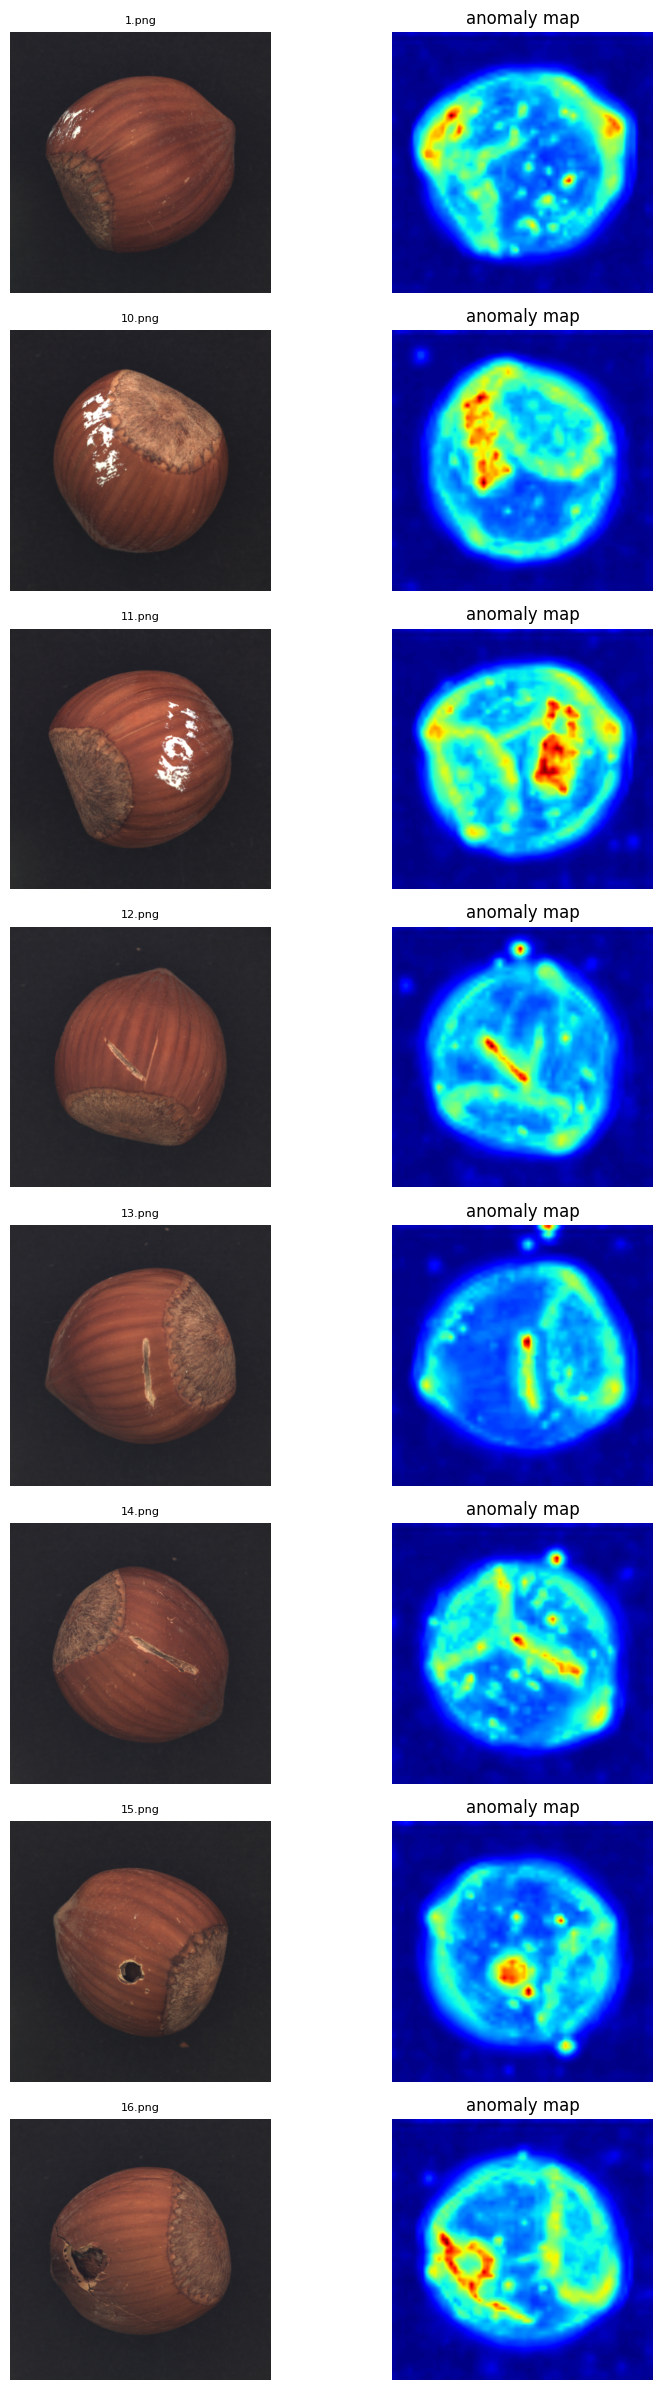

In [8]:
# Visualize test images alongside their predicted anomaly maps.
# Re-glob WITHOUT sorting so the order matches the test loop that built anomaly_maps.
test_paths_vis = list(Path(f'{path}/data/test').glob('*.png'))

n_show = min(8, len(test_paths_vis))
fig, axes = plt.subplots(n_show, 2, figsize=(9, 3 * n_show))
if n_show == 1:
    axes = axes[None, :]

for row in range(n_show):
    img = np.array(Image.open(test_paths_vis[row]).convert('RGB'))
    amap = anomaly_maps[row]  # uint8 (1024, 1024)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(test_paths_vis[row].name, fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(amap, cmap='jet')
    axes[row, 1].set_title('anomaly map')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
submission = pd.DataFrame(columns=["data"])

for i, anomaly_map in enumerate(tqdm(anomaly_maps, desc="Encoding")):
    submission.loc[i] = base64.b85encode(anomaly_map.tobytes()).decode("ascii")

submission = submission.reset_index()
submission.columns = ["id", "data"]

submission.head()

Encoding: 100%|██████████| 70/70 [00:14<00:00,  4.84it/s]


,id,data
0,0,1_lNO1_lNO1_lQQ2L}fS2L}fS2nYxW2nYxW2nYxW2nYxW2...
1,1,2?+@a2?+@a3JMAe3kwVk3=Itp4h{|v4-XFy4-XFy4-XFy4...
2,2,1_lNO1_lNO1_lNO1_lNO1_lNO1_lNO1_lNP2L}fS2M7oV2...
3,3,2?+@a2?+@a2?+@a2?+@a2nYxW2nYxW2nYxW2nYxW2nYxW2...
4,4,1_lNO1_lNO1_lQQ2L}fT2nYxW2nh)Z2?`1d3JMDg3kwVk3...


In [10]:
submission.to_csv(f"submission.csv", index=False)